In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullAFTFitter

df = pd.read_parquet("../data/processed/analysis_ready.parquet")
print(df.shape)
df.head()

(301457, 74)


,geopin,move_in,move_out,purchase_price,sale_price,name,type,zoningclassification,zoningdescription,residential,...,katrina_tenure,fema_category,black_white_other,income_adjusted,income_trim_flag,move_out_year,move_in_year,census_income,census_percent_black_ho,census_black_categories_ho
0,41049784,9065,11893.0,NaN,NaN,Joseph,Street,HU-RD2,Historic Urban Two-Family Residential District,1,...,0,500,NaN,NaN,False,1992.0,1984,173520.960078,NaN,0
1,41049784,11893,15931.0,NaN,0.0,Joseph,Street,HU-RD2,Historic Urban Two-Family Residential District,1,...,0,500,NaN,NaN,False,2003.0,1992,161483.887656,0.018824,0
2,41049784,15964,19184.0,0.0,495957.0,Joseph,Street,HU-RD2,Historic Urban Two-Family Residential District,1,...,1,500,NaN,NaN,False,2012.0,2003,159905.898438,0.017284,0
3,41049784,19184,NaN,495957.0,NaN,Joseph,Street,HU-RD2,Historic Urban Two-Family Residential District,1,...,0,500,NaN,NaN,False,NaN,2012,159905.898438,0.017284,0
4,41026951,11882,21486.0,NaN,454750.0,Lowerline,Street,HU-RD2,Historic Urban Two-Family Residential District,1,...,1,0,1.0,81.06,False,2018.0,1992,NaN,NaN,0


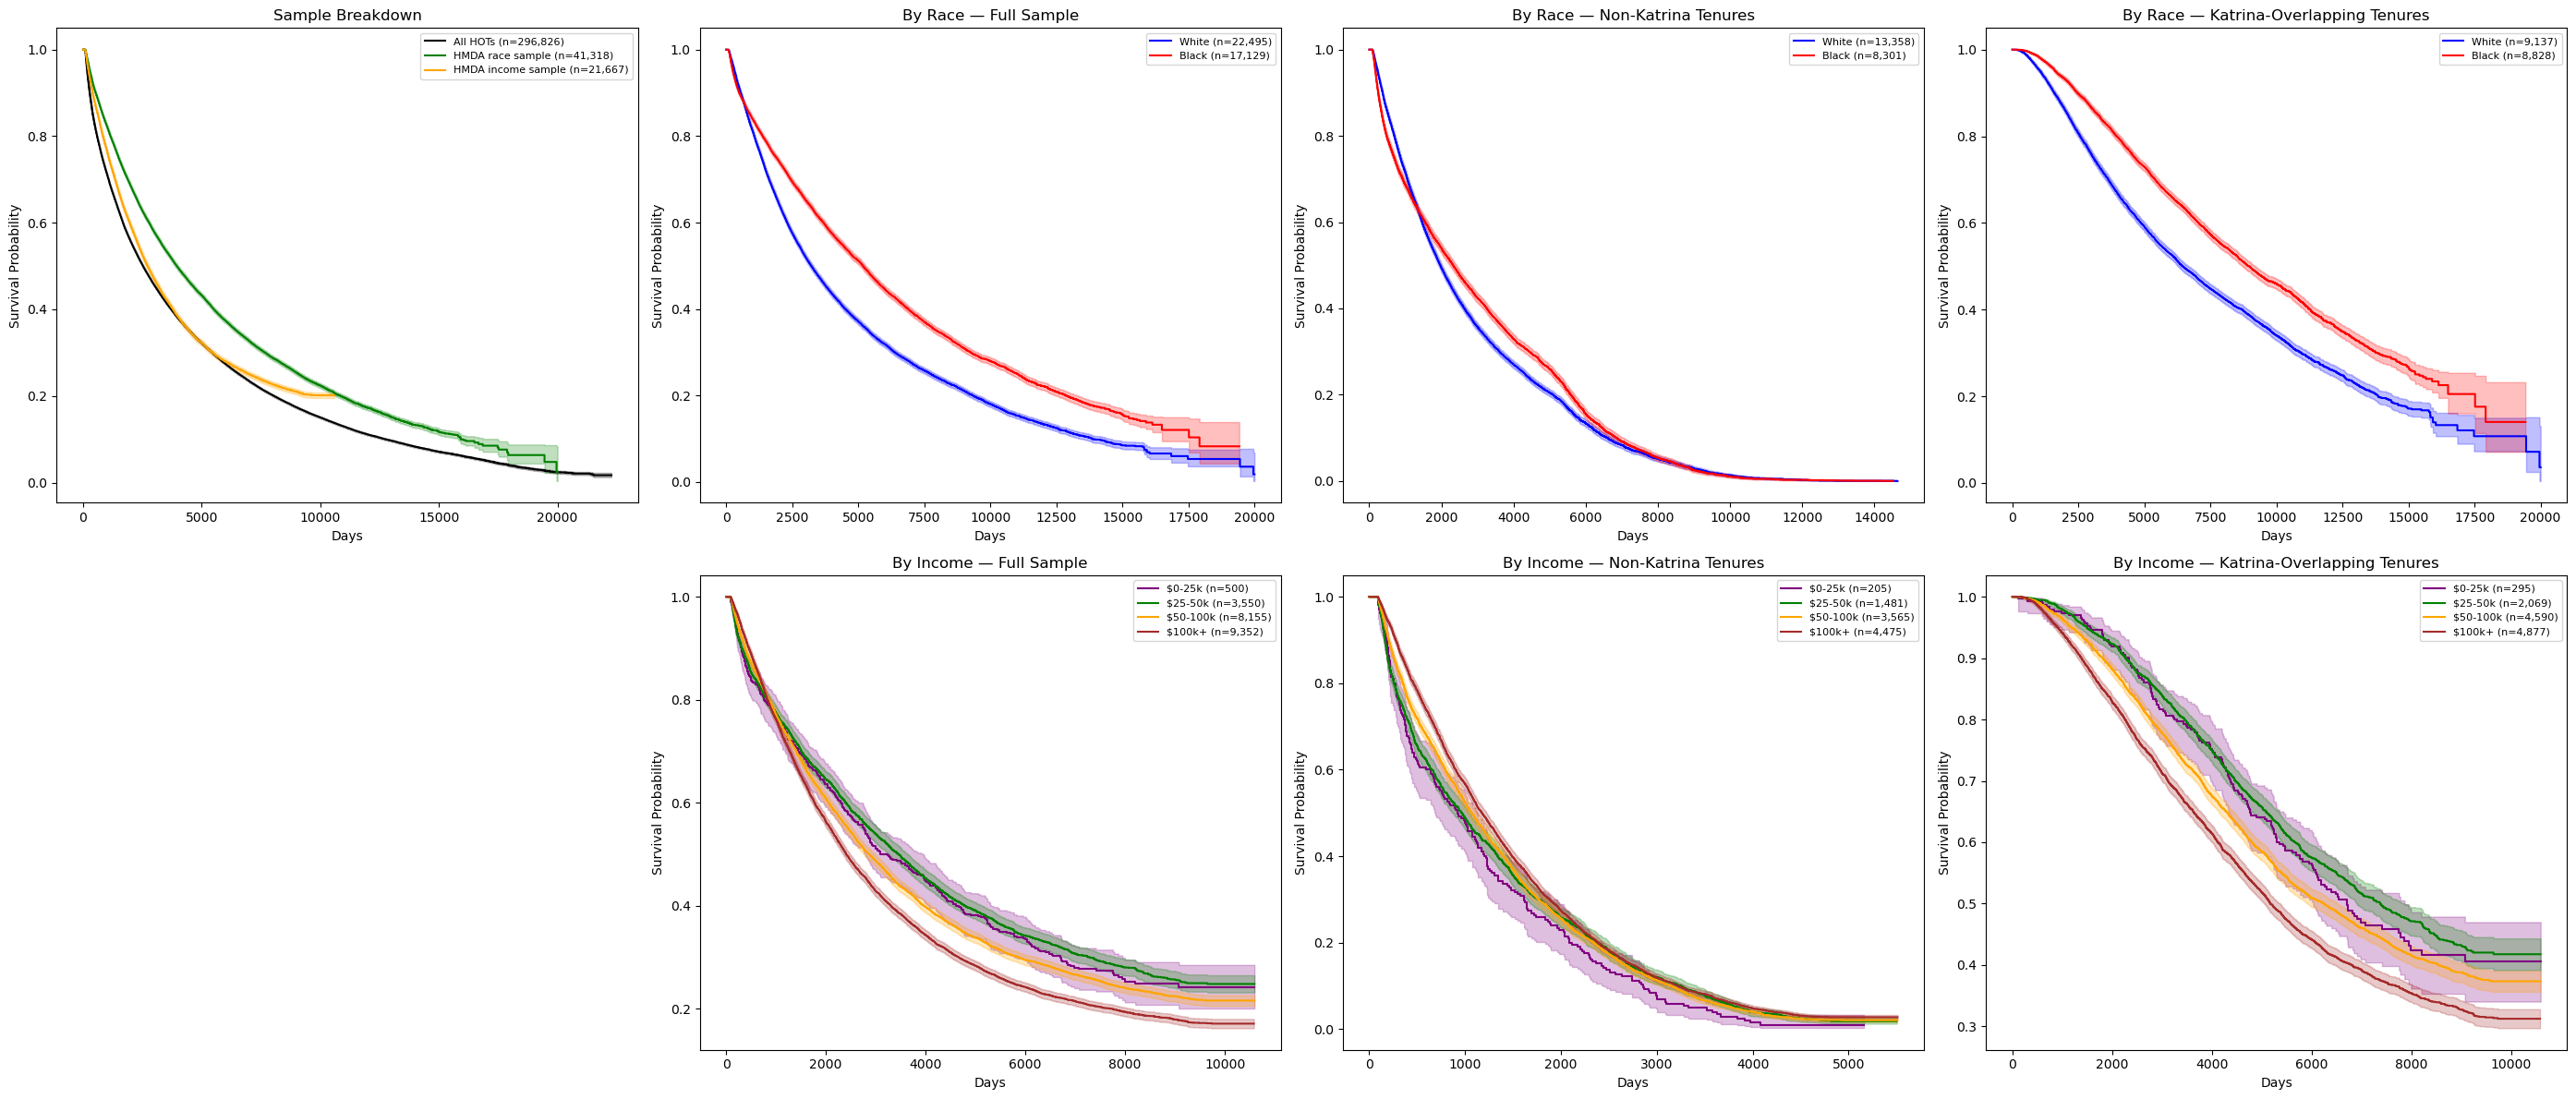

In [11]:
# trim to Stata day 0 (Jan 1 1960) -- removes pre-1960 move_in dates
# TODO: move this trim to 02_features.py, and evaluate appropriate cutoff
df_trim = df[df['move_in'] >= 0].copy()

income_cuts = [0, 25, 50, 100, 500]
income_labels = ['$0-25k', '$25-50k', '$50-100k', '$100k+']
income_colors = ['purple', 'green', 'orange', 'brown']

df_trim['income_cut'] = pd.cut(df_trim['income_adjusted'], bins=income_cuts, labels=income_labels)

fig, axes = plt.subplots(2, 4, figsize=(28, 12))

# ── panel 1: sample breakdown ─────────────────────────────────
ax = axes[0, 0]
for mask, label, color in [
    (df_trim['duration'].notna(), 'All HOTs', 'black'),
    (df_trim['black_white_other'].notna(), 'HMDA race sample', 'green'),
    (df_trim['income_adjusted'].notna() & ~df_trim['income_trim_flag'], 'HMDA income sample', 'orange'),
]:
    n = mask.sum()
    kmf = KaplanMeierFitter()
    kmf.fit(df_trim.loc[mask, 'duration'], df_trim.loc[mask, 'moved_out'],
            label=f'{label} (n={n:,})')
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True)
ax.set_title('Sample Breakdown')
ax.set_xlabel('Days')
ax.set_ylabel('Survival Probability')
ax.legend(fontsize=8)

# ── row 1: race panels ────────────────────────────────────────
race_panels = [
    (axes[0, 1], None, 'By Race — Full Sample'),
    (axes[0, 2], 0,    'By Race — Non-Katrina Tenures'),
    (axes[0, 3], 1,    'By Race — Katrina-Overlapping Tenures'),
]
for ax, katrina_val, title in race_panels:
    for race, label, color in [(1, 'White', 'blue'), (2, 'Black', 'red')]:
        if katrina_val is None:
            mask = df_trim['black_white_other'] == race
        else:
            mask = (df_trim['black_white_other'] == race) & (df_trim['katrina_tenure'] == katrina_val)
        n = mask.sum()
        kmf = KaplanMeierFitter()
        kmf.fit(df_trim.loc[mask, 'duration'], df_trim.loc[mask, 'moved_out'],
                label=f'{label} (n={n:,})')
        kmf.plot_survival_function(ax=ax, color=color, ci_show=True)
    ax.set_title(title)
    ax.set_xlabel('Days')
    ax.set_ylabel('Survival Probability')
    ax.legend(fontsize=8)

# ── row 2: income panels ──────────────────────────────────────
income_panels = [
    (axes[1, 1], None, 'By Income — Full Sample'),
    (axes[1, 2], 0,    'By Income — Non-Katrina Tenures'),
    (axes[1, 3], 1,    'By Income — Katrina-Overlapping Tenures'),
]
for ax, katrina_val, title in income_panels:
    for label, color in zip(income_labels, income_colors):
        if katrina_val is None:
            mask = df_trim['income_cut'] == label
        else:
            mask = (df_trim['income_cut'] == label) & (df_trim['katrina_tenure'] == katrina_val)
        n = mask.sum()
        kmf = KaplanMeierFitter()
        kmf.fit(df_trim.loc[mask, 'duration'], df_trim.loc[mask, 'moved_out'],
                label=f'{label} (n={n:,})')
        kmf.plot_survival_function(ax=ax, color=color, ci_show=True)
    ax.set_title(title)
    ax.set_xlabel('Days')
    ax.set_ylabel('Survival Probability')
    ax.legend(fontsize=8, loc='upper right')

# ── bottom left: empty ────────────────────────────────────────
axes[1, 0].axis('off')

plt.tight_layout()
plt.show()

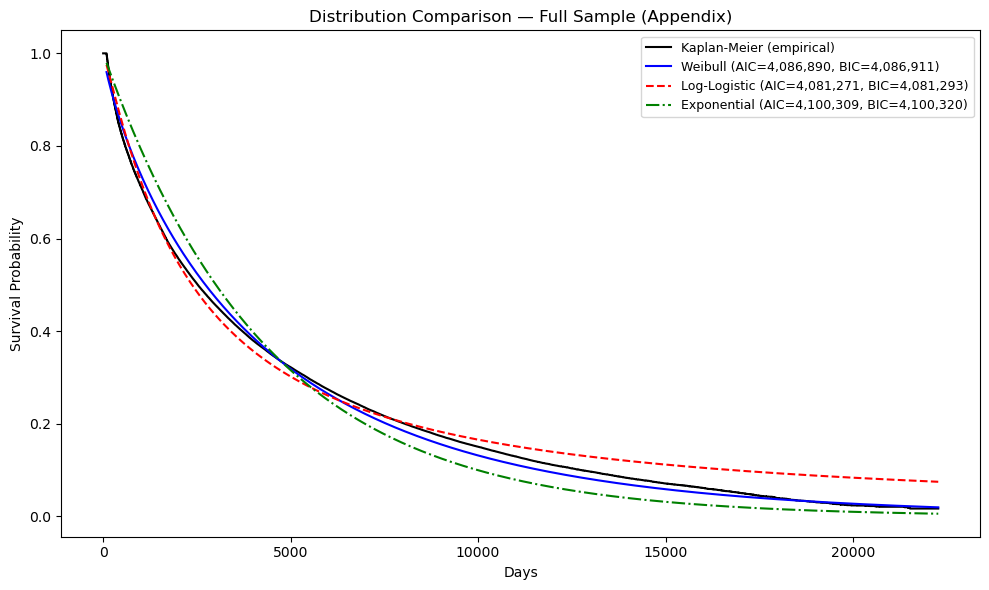

In [13]:
from lifelines import WeibullFitter, LogLogisticFitter, ExponentialFitter

fig, ax = plt.subplots(figsize=(10, 6))

# empirical KM
kmf = KaplanMeierFitter()
kmf.fit(df_trim['duration'], df_trim['moved_out'], label='Kaplan-Meier (empirical)')
kmf.plot_survival_function(ax=ax, color='black', ci_show=False)

# parametric fits
for fitter, label, color, ls in [
    (WeibullFitter(),     'Weibull',      'blue',  '-'),
    (LogLogisticFitter(), 'Log-Logistic', 'red',   '--'),
    (ExponentialFitter(), 'Exponential',  'green', '-.'),
]:
    fitter.fit(df_trim['duration'], df_trim['moved_out'])
    full_label = f'{label} (AIC={fitter.AIC_:,.0f}, BIC={fitter.BIC_:,.0f})'
    fitter.plot_survival_function(ax=ax, color=color, linestyle=ls, 
                                  ci_show=False, label=full_label)

ax.set_title('Distribution Comparison — Full Sample (Appendix)')
ax.set_xlabel('Days')
ax.set_ylabel('Survival Probability')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
# create dummies for triple interaction
# reference categories: white, outside flood zone, no katrina
# FLAG: fema dummies introduced here -- consider whether fema_category
# should be constructed earlier in 02_features.py

# race dummies (ref = white, black_white_other == 1)
df_trim['black'] = (df_trim['black_white_other'] == 2).astype(int)
df_trim['other_race'] = (df_trim['black_white_other'] == 0).astype(int)

# fema dummies (ref = outside, fema_category == 0)
df_trim['fema_100'] = (df_trim['fema_category'] == 100).astype(int)
df_trim['fema_500'] = (df_trim['fema_category'] == 500).astype(int)

# interaction terms
df_trim['black_x_katrina'] = df_trim['black'] * df_trim['katrina_tenure']
df_trim['other_x_katrina'] = df_trim['other_race'] * df_trim['katrina_tenure']
df_trim['fema100_x_katrina'] = df_trim['fema_100'] * df_trim['katrina_tenure']
df_trim['fema500_x_katrina'] = df_trim['fema_500'] * df_trim['katrina_tenure']
df_trim['black_x_fema100'] = df_trim['black'] * df_trim['fema_100']
df_trim['black_x_fema500'] = df_trim['black'] * df_trim['fema_500']
df_trim['other_x_fema100'] = df_trim['other_race'] * df_trim['fema_100']
df_trim['other_x_fema500'] = df_trim['other_race'] * df_trim['fema_500']
df_trim['black_x_fema100_x_katrina'] = df_trim['black'] * df_trim['fema_100'] * df_trim['katrina_tenure']
df_trim['black_x_fema500_x_katrina'] = df_trim['black'] * df_trim['fema_500'] * df_trim['katrina_tenure']
df_trim['other_x_fema100_x_katrina'] = df_trim['other_race'] * df_trim['fema_100'] * df_trim['katrina_tenure']
df_trim['other_x_fema500_x_katrina'] = df_trim['other_race'] * df_trim['fema_500'] * df_trim['katrina_tenure']

# cox PH -- HMDA race subsample
cox_cols = [
    'black', 'other_race', 'fema_100', 'fema_500', 'katrina_tenure',
    'black_x_katrina', 'other_x_katrina',
    'fema100_x_katrina', 'fema500_x_katrina',
    'black_x_fema100', 'black_x_fema500',
    'other_x_fema100', 'other_x_fema500',
    'black_x_fema100_x_katrina', 'black_x_fema500_x_katrina',
    'other_x_fema100_x_katrina', 'other_x_fema500_x_katrina',
]

hmda_race = df_trim[df_trim['black_white_other'].notna()].copy()

cph = CoxPHFitter()
cph.fit(hmda_race[cox_cols + ['duration', 'moved_out']], 
        duration_col='duration', 
        event_col='moved_out',
        cluster_col=None)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 41318 total observations, 12280 right-censored observations>
             duration col = 'duration'
                event col = 'moved_out'
      baseline estimation = breslow
   number of observations = 41318
number of events observed = 29038
   partial log-likelihood = -282636.53
         time fit was run = 2026-08-20 18:21:32 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                  
black                     -0.15      0.86      0.03           -0.21           -0.09                0.81                0.92
other_race                 0.07      1.07      0.06           -0.05            0.18                0.95                1.20
fema_100                   0.12      1.13      0.03            0.07            0.18                1.07                1.19
fema_500                   0.04      1.04      0.02           -0.00            0.08                1.00                1.09
katrina_tenure            -1.29      0.27      0.02           -1.34           -1.25                0.26                0.29
black_x_katrina           -0.22      0.80      0.05           -0.32           -0.13                0.73                0.88
other_x_katrina           -0.15      0.86      0.10           -0.35            0.05                0.70                1.05
fema100_x_katrina          0.08      1.08      0.05           -0.02            0.17                0.98                1.19
fema500_x_katrina         -0.05      0.95      0.04           -0.12            0.02                0.89                1.02
black_x_fema100            0.01      1.01      0.05           -0.09            0.11                0.91                1.12
black_x_fema500            0.04      1.04      0.04           -0.04            0.11                0.96                1.12
other_x_fema100           -0.11      0.90      0.11           -0.32            0.11                0.73                1.12
other_x_fema500           -0.12      0.89      0.08           -0.28            0.04                0.76                1.04
black_x_fema100_x_katrina  0.07      1.07      0.08           -0.10            0.24                0.91                1.27
black_x_fema500_x_katrina -0.04      0.96      0.06           -0.17            0.08                0.85                1.08
other_x_fema100_x_katrina  0.06      1.06      0.19           -0.31            0.43                0.73                1.54
other_x_fema500_x_katrina -0.17      0.84      0.14           -0.44            0.10                0.64                1.10

                           cmp to      z      p  -log2(p)
covariate                                                
black                        0.00  -4.85 <0.005     19.60
other_race                   0.00   1.16   0.25      2.03
fema_100                     0.00   4.24 <0.005     15.42
fema_500                     0.00   1.87   0.06      4.02
katrina_tenure               0.00 -57.55 <0.005       inf
black_x_katrina              0.00  -4.52 <0.005     17.28
other_x_katrina              0.00  -1.47   0.14      2.81
fema100_x_katrina            0.00   1.58   0.11      3.14
fema500_x_katrina            0.00  -1.32   0.19      2.42
black_x_fema100              0.00   0.18   0.86      0.22
black_x_fema500              0.00   0.98   0.32      1.62
other_x_fema100              0.00  -0.95   0.34      1.55
other_x_fema500              0.00  -1.49   0.14      2.88
black_x_fema100_x_katrina    0.00   0.83   0.41      1.29
black_x_fema500_x_katrina    0.00  -0.72   0.47      1.09
other_x_fema100_x_katrina    0.00   0.32   0.75      0.42
other_x_fema500_x_katrina    0.00  -1.27   0.20      2.29
---
Concordance = 0.68
Partial AIC = 565307.07
log-likelihood ratio test = 12534.21 on 17 df
-log2(p) of ll-ratio test = inf

In [15]:
print('geopin' in df_trim.columns)

True


In [17]:
waf = WeibullAFTFitter()
waf.fit(hmda_race[cox_cols + ['duration', 'moved_out']], 
        duration_col='duration', 
        event_col='moved_out',
        robust=True)

waf.print_summary()

<lifelines.WeibullAFTFitter: fitted with 41318 total observations, 12280 right-censored observations>
             duration col = 'duration'
                event col = 'moved_out'
          robust variance = True
   number of observations = 41318
number of events observed = 29038
           log-likelihood = -275705.17
         time fit was run = 2026-08-20 18:32:22 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                  
lambda_ black                      0.14      1.15      0.03            0.08            0.19                1.08                1.21
        black_x_fema100           -0.01      0.99      0.05           -0.10            0.09                0.90                1.09
        black_x_fema100_x_katrina -0.06      0.94      0.08           -0.21            0.09                0.81                1.09
        black_x_fema500           -0.03      0.97      0.04           -0.10            0.04                0.90                1.04
        black_x_fema500_x_katrina  0.04      1.04      0.06           -0.07            0.15                0.94                1.16
        black_x_katrina            0.18      1.20      0.04            0.10            0.27                1.10                1.31
        fema100_x_katrina         -0.06      0.94      0.04           -0.15            0.02                0.86                1.02
        fema500_x_katrina          0.04      1.05      0.03           -0.02            0.11                0.98                1.11
        fema_100                  -0.11      0.89      0.03           -0.16           -0.06                0.85                0.94
        fema_500                  -0.04      0.96      0.02           -0.08            0.00                0.92                1.00
        katrina_tenure             1.13      3.08      0.02            1.09            1.16                2.96                3.20
        other_race                -0.06      0.94      0.05           -0.17            0.04                0.85                1.05
        other_x_fema100            0.10      1.10      0.10           -0.10            0.29                0.90                1.34
        other_x_fema100_x_katrina -0.05      0.95      0.17           -0.38            0.28                0.68                1.32
        other_x_fema500            0.11      1.12      0.07           -0.03            0.26                0.97                1.29
        other_x_fema500_x_katrina  0.15      1.16      0.12           -0.09            0.38                0.92                1.47
        other_x_katrina            0.13      1.14      0.09           -0.04            0.31                0.96                1.36
        Intercept                  8.03   3058.45      0.01            8.00            8.05             2988.70             3129.83
rho_    Intercept                  0.11      1.12      0.00            0.11            0.12                1.11                1.13

                                   cmp to      z      p  -log2(p)
param   covariate                                                
lambda_ black                        0.00   4.85 <0.005     19.64
        black_x_fema100              0.00  -0.15   0.88      0.19
        black_x_fema100_x_katrina    0.00  -0.79   0.43      1.21
        black_x_fema500              0.00  -0.92   0.36      1.48
        black_x_fema500_x_katrina    0.00   0.77   0.44      1.17
        black_x_katrina              0.00   4.19 <0.005     15.14
        fema100_x_katrina            0.00  -1.42   0.16      2.69
        fema500_x_katrina            0.00   1.34   0.18      2.48
        fema_100                     0.00  -4.24 <0.005     15.44
        fema_500                     0.00  -1.91   0.06      4.16
        katrina_tenure               0.00  57.02 <0.005  